# EDA — Inventario Mensual (`im.csv`)

Dataset de inventarios con ~7.9 millones de registros. Cubre diferencias de inventario por producto, almacén y sucursal entre 2016 y 2026.

**Columnas clave:**
| Columna | Descripción |
|---|---|
| `idinventariomes` | ID del conteo de inventario |
| `idempresa` / `idsucursal` / `idalmacen` | Jerarquía organizacional |
| `idproducto` / `producto_nombre` | Producto contado |
| `idcategoria` | Categoría del producto (1, 2, 3) |
| `inventariomes_fecha` | Fecha del conteo |
| `inventariomes_revisada` | Si el conteo fue revisado (1=sí, 0=no) |
| `inventariomesdetalle_diferencia` | Diferencia en unidades (físico − sistema) |
| `inventariomesdetalle_difimporte` | Diferencia valorizada en $ |
| `inventariomesdetalle_costopromedio` | Costo promedio unitario del producto |

## 0. Librerías y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Estilo general de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (12, 4)})
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

FILE = 'im.csv'

## 1. Carga de datos

El archivo tiene ~7.9 M filas. Cargamos una muestra aleatoria estratificada (500 k filas) para el análisis exploratorio y reservamos la carga completa para estadísticas globales que lo requieran.

In [2]:
# --- Conteo total de filas sin cargar todo en memoria ---
total_rows = sum(1 for _ in open(FILE)) - 1  # descuenta el header
print(f'Total de registros en el archivo: {total_rows:,}')

# --- Carga completa (puede tardar ~30s dependiendo del equipo) ---
dtype_map = {
    'idinventariomes': 'int32',
    'idempresa':       'int8',
    'idsucursal':      'int8',
    'idalmacen':       'int16',
    'idproducto':      'int32',
    'inventariomes_revisada': 'int8',
    'idcategoria':     'int8',
}

df = pd.read_csv(
    FILE,
    dtype=dtype_map,
    parse_dates=['inventariomes_fecha'],
)

print(f'Filas cargadas : {len(df):,}')
print(f'Columnas       : {df.shape[1]}')
print(f'Memoria aprox. : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Total de registros en el archivo: 7,964,177
Filas cargadas : 7,964,177
Columnas       : 13
Memoria aprox. : 1421.0 MB


## 2. Vista rápida del DataFrame

In [3]:
display(df.head(5))
display(df.tail(3))

,idinventariomes,idempresa,idsucursal,idalmacen,idproducto,inventariomes_fecha,inventariomes_revisada,inventariomesdetalle_diferencia,inventariomesdetalle_difimporte,inventariomesdetalle_costopromedio,almacen_nombre,producto_nombre,idcategoria
0,4207,3,9,53,65933,2017-10-01,1,48.00,"2,724.00",56.75,Almacén general,CINTURON DAMA,3
1,4209,3,9,53,65933,2017-10-08,1,0.00,0.00,56.75,Almacén general,CINTURON DAMA,3
2,4789,3,9,53,65933,2017-10-15,1,0.00,0.00,56.75,Almacén general,CINTURON DAMA,3
3,4790,3,9,53,65933,2017-10-22,1,0.00,0.00,56.75,Almacén general,CINTURON DAMA,3
4,4791,3,9,53,65933,2017-10-29,1,0.00,0.00,56.75,Almacén general,CINTURON DAMA,3


,idinventariomes,idempresa,idsucursal,idalmacen,idproducto,inventariomes_fecha,inventariomes_revisada,inventariomesdetalle_diferencia,inventariomesdetalle_difimporte,inventariomesdetalle_costopromedio,almacen_nombre,producto_nombre,idcategoria
7964174,117742,-109,-27,18300,205600,2026-03-22,1,-0.00,-0.09,43.76,Reposteria,AZUCAR GLASS KG,1
7964175,118267,-109,-27,18300,205600,2026-03-31,1,-0.41,-18.01,43.76,Reposteria,AZUCAR GLASS KG,1
7964176,118575,-109,-27,18300,205600,2026-04-05,1,-0.09,-3.87,45.00,Reposteria,AZUCAR GLASS KG,1


In [7]:
df.columns.tolist()

['idinventariomes',
 'idempresa',
 'idsucursal',
 'idalmacen',
 'idproducto',
 'inventariomes_fecha',
 'inventariomes_revisada',
 'inventariomesdetalle_diferencia',
 'inventariomesdetalle_difimporte',
 'inventariomesdetalle_costopromedio',
 'almacen_nombre',
 'producto_nombre',
 'idcategoria']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7964177 entries, 0 to 7964176
Data columns (total 13 columns):
 #   Column                              Dtype         
---  ------                              -----         
 0   idinventariomes                     int32         
 1   idempresa                           int8          
 2   idsucursal                          int8          
 3   idalmacen                           int16         
 4   idproducto                          int32         
 5   inventariomes_fecha                 datetime64[ns]
 6   inventariomes_revisada              int8          
 7   inventariomesdetalle_diferencia     float64       
 8   inventariomesdetalle_difimporte     float64       
 9   inventariomesdetalle_costopromedio  float64       
 10  almacen_nombre                      object        
 11  producto_nombre                     object        
 12  idcategoria                         int8          
dtypes: datetime64[ns](1), float64(3), int16(1)

## 3. Calidad de datos

### 3.1 Valores nulos

In [5]:
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'nulos': nulls, 'pct_%': null_pct})
null_df = null_df[null_df['nulos'] > 0]

if null_df.empty:
    print('✓ Sin valores nulos en ninguna columna.')
else:
    display(null_df)

✓ Sin valores nulos en ninguna columna.


### 3.2 Duplicados

In [6]:
dupes = df.duplicated().sum()
print(f'Filas duplicadas (100% idénticas): {dupes:,}  ({dupes/len(df)*100:.2f}%)')

# Verificar unicidad del ID primario
id_dupes = df.duplicated(subset=['idinventariomes', 'idproducto']).sum()
print(f'Duplicados por (idinventariomes, idproducto): {id_dupes:,}')

Filas duplicadas (100% idénticas): 2,228  (0.03%)
Duplicados por (idinventariomes, idproducto): 2,998


### 3.3 Cardinalidad de columnas categóricas

In [8]:
cat_cols = ['idempresa', 'idsucursal', 'idalmacen', 'idcategoria',
            'almacen_nombre', 'inventariomes_revisada']

for col in cat_cols:
    print(f'{col:35s}  únicos={df[col].nunique():>4}   valores: {sorted(df[col].unique())}')

idempresa                            únicos=  66   valores: [np.int8(-128), np.int8(-125), np.int8(-123), np.int8(-112), np.int8(-110), np.int8(-109), np.int8(-108), np.int8(-107), np.int8(-105), np.int8(-100), np.int8(-95), np.int8(-93), np.int8(-92), np.int8(-88), np.int8(-87), np.int8(-83), np.int8(-81), np.int8(-78), np.int8(-75), np.int8(-71), np.int8(-70), np.int8(-69), np.int8(-68), np.int8(-63), np.int8(-60), np.int8(-59), np.int8(-58), np.int8(-53), np.int8(-45), np.int8(-20), np.int8(-19), np.int8(-17), np.int8(-15), np.int8(-13), np.int8(-12), np.int8(-9), np.int8(-6), np.int8(-5), np.int8(-1), np.int8(3), np.int8(6), np.int8(7), np.int8(8), np.int8(9), np.int8(10), np.int8(11), np.int8(13), np.int8(14), np.int8(20), np.int8(22), np.int8(26), np.int8(27), np.int8(50), np.int8(52), np.int8(55), np.int8(59), np.int8(66), np.int8(81), np.int8(82), np.int8(84), np.int8(90), np.int8(100), np.int8(108), np.int8(109), np.int8(114), np.int8(123)]
idsucursal                          

## 4. Estadísticas descriptivas

In [9]:
num_cols = [
    'inventariomesdetalle_diferencia',
    'inventariomesdetalle_difimporte',
    'inventariomesdetalle_costopromedio',
]

stats = df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
display(stats)

,inventariomesdetalle_diferencia,inventariomesdetalle_difimporte,inventariomesdetalle_costopromedio
count,"7,964,177.00","7,964,177.00","7,964,177.00"
mean,-138.65,"415,654.84",267.42
std,"613,749.62","1,529,992,282.49","1,568.94"
min,"-999,999,999.00","-555,219,992,782.14",0.01
1%,-319.00,"-5,087.90",0.42
5%,-29.00,"-1,042.76",4.00
25%,-1.00,-50.47,27.10
50%,0.00,0.00,100.00
75%,0.20,21.25,285.79
95%,13.69,750.07,877.17


In [10]:
# Asimetría y curtosis — ayudan a detectar colas pesadas y outliers
skew_kurt = pd.DataFrame({
    'skewness': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurtosis(),
})
display(skew_kurt)

,skewness,kurtosis
inventariomesdetalle_diferencia,-543.11,"2,654,698.57"
inventariomesdetalle_difimporte,"2,711.25","7,582,209.48"
inventariomesdetalle_costopromedio,578.25,"815,252.61"


## 5. Análisis temporal

### 5.1 Rango de fechas y granularidad

In [11]:
print(f'Fecha mínima : {df["inventariomes_fecha"].min()}')
print(f'Fecha máxima : {df["inventariomes_fecha"].max()}')
print(f'Años cubiertos: {df["inventariomes_fecha"].dt.year.nunique()}  '
      f'({df["inventariomes_fecha"].dt.year.min()} – {df["inventariomes_fecha"].dt.year.max()})')

df['año']      = df['inventariomes_fecha'].dt.year
df['mes']      = df['inventariomes_fecha'].dt.month
df['dia_sem']  = df['inventariomes_fecha'].dt.day_name()
df['año_mes']  = df['inventariomes_fecha'].dt.to_period('M')

Fecha mínima : 2016-10-02 00:00:00
Fecha máxima : 2026-04-12 00:00:00
Años cubiertos: 11  (2016 – 2026)


### 5.2 Volumen de conteos por mes

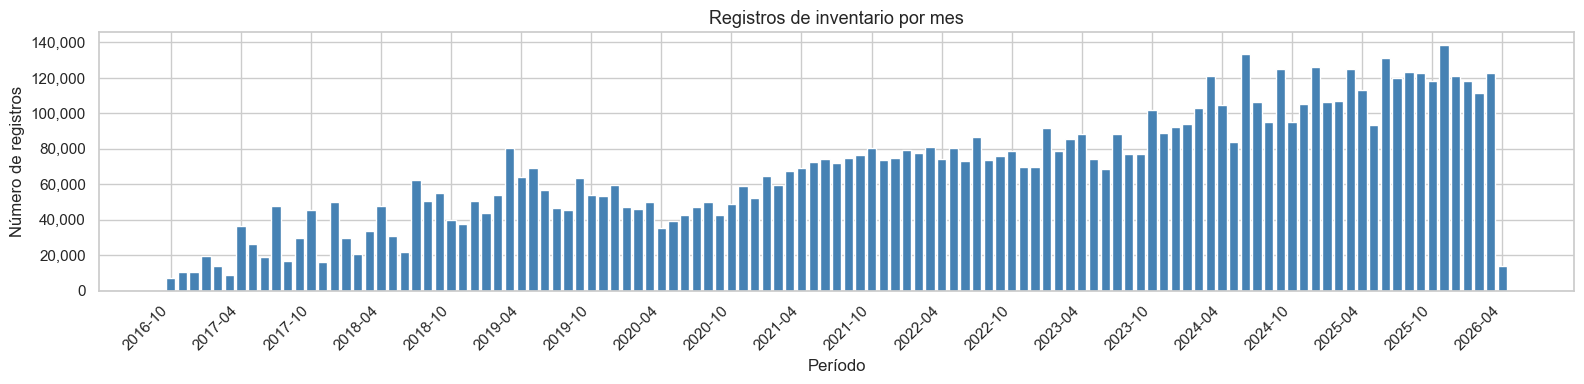

In [12]:
vol_mes = df.groupby('año_mes').size().reset_index(name='registros')
vol_mes['año_mes_str'] = vol_mes['año_mes'].astype(str)

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(vol_mes['año_mes_str'], vol_mes['registros'], color='steelblue', width=0.8)
ax.set_title('Registros de inventario por mes', fontsize=13)
ax.set_xlabel('Período')
ax.set_ylabel('Número de registros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Mostrar solo cada 6 meses para no saturar el eje X
ticks = vol_mes['año_mes_str'].tolist()
ax.set_xticks(ticks[::6])
ax.set_xticklabels(ticks[::6], rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Diferencias de inventario acumuladas por año

,año,dif_unidades,dif_importe,conteos
0,2016,"-396,941.55","-4,905,523.88",28220
1,2017,"-3,952,683.75","-37,611,295.14",330034
2,2018,"-6,832,847.04","14,689,496.92",480994
3,2019,"-10,084,082.33","-53,005,198.42",691145
4,2020,"-7,890,145.63","-15,078,644.54",559636
5,2021,"-10,606,883.54","306,758,662.17",860369
6,2022,"-1,014,659,977.86","-555,345,904,110.47",920569
7,2023,"-16,844,587.71","-1,542,622,572.80",1012651
8,2024,"-15,997,535.43","-13,582,675,451.67",1293695
9,2025,"-14,039,472.40","3,880,644,565,647.98",1420262


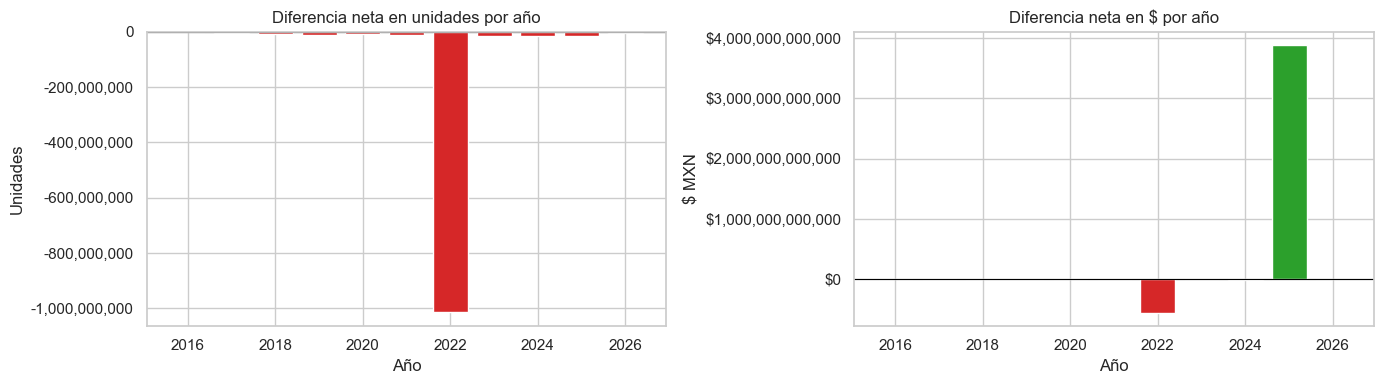

In [13]:
dif_anual = df.groupby('año').agg(
    dif_unidades=('inventariomesdetalle_diferencia', 'sum'),
    dif_importe =('inventariomesdetalle_difimporte',  'sum'),
    conteos     =('idinventariomes', 'count'),
).reset_index()

display(dif_anual)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(dif_anual['año'], dif_anual['dif_unidades'],
            color=['#d62728' if v < 0 else '#2ca02c' for v in dif_anual['dif_unidades']])
axes[0].set_title('Diferencia neta en unidades por año')
axes[0].set_xlabel('Año'); axes[0].set_ylabel('Unidades')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].axhline(0, color='black', linewidth=0.8)

axes[1].bar(dif_anual['año'], dif_anual['dif_importe'],
            color=['#d62728' if v < 0 else '#2ca02c' for v in dif_anual['dif_importe']])
axes[1].set_title('Diferencia neta en $ por año')
axes[1].set_xlabel('Año'); axes[1].set_ylabel('$ MXN')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 6. Distribución de variables numéricas

### 6.1 Distribución de la diferencia de inventario (unidades)

In [14]:
dif = df['inventariomesdetalle_diferencia']

print(f'Registros con diferencia = 0   : {(dif == 0).sum():>10,}  ({(dif == 0).mean()*100:.1f}%)')
print(f'Registros con diferencia > 0   : {(dif > 0).sum():>10,}  ({(dif > 0).mean()*100:.1f}%)  (sobrante)')
print(f'Registros con diferencia < 0   : {(dif < 0).sum():>10,}  ({(dif < 0).mean()*100:.1f}%)  (faltante)')

Registros con diferencia = 0   :  2,424,976  (30.4%)
Registros con diferencia > 0   :  2,688,466  (33.8%)  (sobrante)
Registros con diferencia < 0   :  2,850,735  (35.8%)  (faltante)


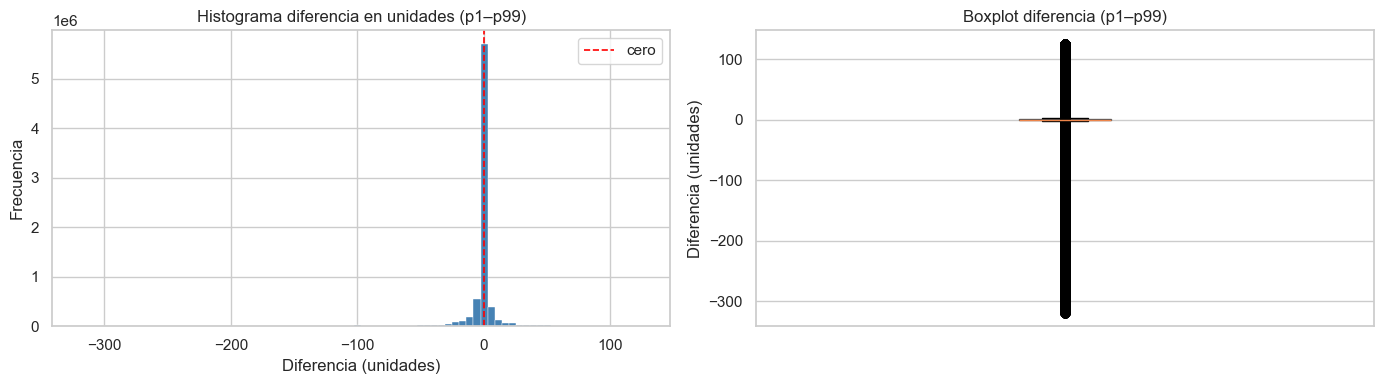

In [15]:
# Filtramos outliers extremos para que el histograma sea legible (percentil 1-99)
p1, p99 = dif.quantile([0.01, 0.99])
dif_trim = dif[(dif >= p1) & (dif <= p99)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dif_trim, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2, label='cero')
axes[0].set_title('Histograma diferencia en unidades (p1–p99)')
axes[0].set_xlabel('Diferencia (unidades)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot para ver la dispersión
axes[1].boxplot(dif_trim, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot diferencia (p1–p99)')
axes[1].set_ylabel('Diferencia (unidades)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

### 6.2 Distribución del importe diferencial ($)

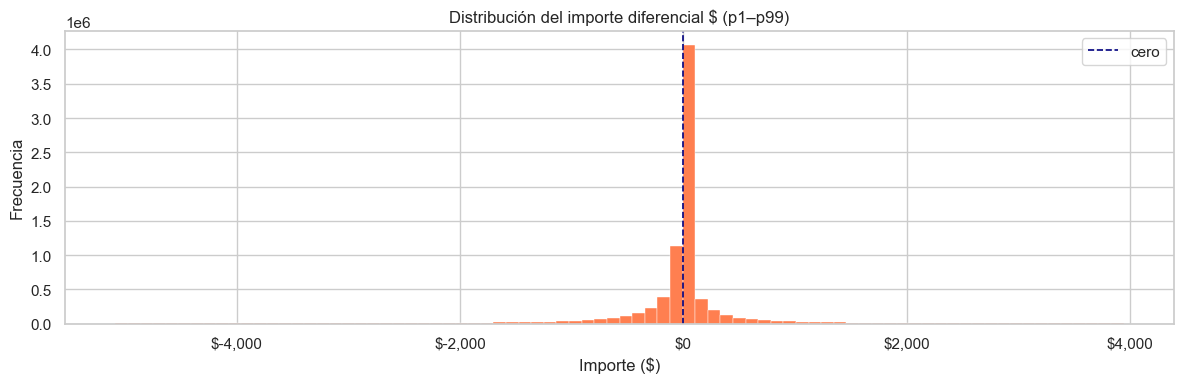

In [16]:
imp = df['inventariomesdetalle_difimporte']
p1i, p99i = imp.quantile([0.01, 0.99])
imp_trim = imp[(imp >= p1i) & (imp <= p99i)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(imp_trim, bins=80, color='coral', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='navy', linestyle='--', linewidth=1.2, label='cero')
ax.set_title('Distribución del importe diferencial $ (p1–p99)')
ax.set_xlabel('Importe ($)')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

### 6.3 Distribución del costo promedio por producto

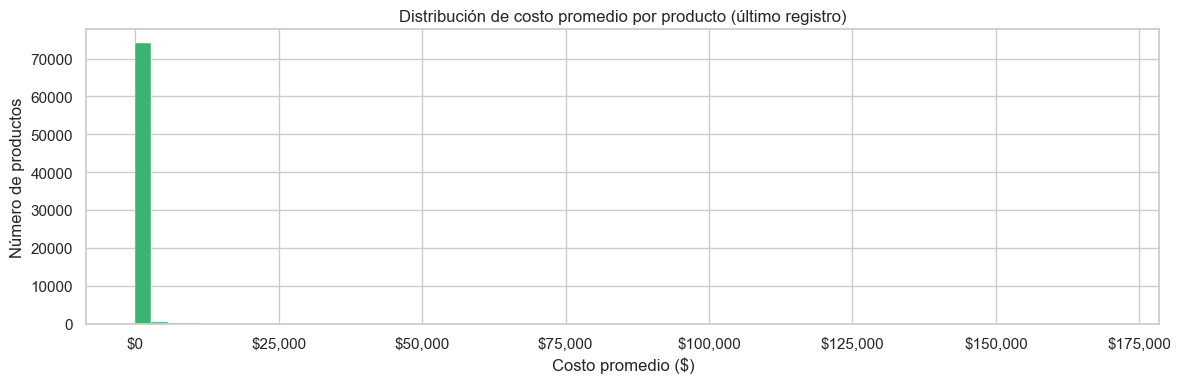


Productos con costo < $1   : 1191
Productos con costo > $500 : 10041
Mediana de costo            : $109.58


In [17]:
# Tomamos el costo promedio más reciente por producto (evita duplicar el mismo producto)
costo_prod = df.sort_values('inventariomes_fecha').groupby('idproducto')['inventariomesdetalle_costopromedio'].last()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(costo_prod, bins=60, color='mediumseagreen', edgecolor='white', linewidth=0.3)
ax.set_title('Distribución de costo promedio por producto (último registro)')
ax.set_xlabel('Costo promedio ($)')
ax.set_ylabel('Número de productos')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print(f'\nProductos con costo < $1   : {(costo_prod < 1).sum()}')
print(f'Productos con costo > $500 : {(costo_prod > 500).sum()}')
print(f'Mediana de costo            : ${costo_prod.median():,.2f}')

## 7. Análisis por variables categóricas

### 7.1 Sucursales

In [18]:
suc = df.groupby('idsucursal').agg(
    registros          =('idinventariomes', 'count'),
    productos_únicos   =('idproducto', 'nunique'),
    dif_media_unidades =('inventariomesdetalle_diferencia', 'mean'),
    dif_total_importe  =('inventariomesdetalle_difimporte', 'sum'),
    pct_revisadas      =('inventariomes_revisada', 'mean'),
).reset_index()
suc['pct_revisadas'] = (suc['pct_revisadas'] * 100).round(1)
display(suc)

,idsucursal,registros,productos_únicos,dif_media_unidades,dif_total_importe,pct_revisadas
0,-126,15859,1151,-17.28,"-38,856,895.22",100.00
1,-123,9384,119,-8.22,"-2,294,200.09",100.00
2,-122,11099,520,-8.10,"-2,809,732.17",100.00
3,-121,19784,486,-4.85,"3,880,845,527,815.66",100.00
4,-120,70690,1533,-17.06,"-3,520,833.87",99.00
...,...,...,...,...,...,...
180,122,8227,362,59.58,"49,990,604.25",91.10
181,124,8402,401,-21.06,"-2,275,924.67",100.00
182,125,972,269,-1.04,"-318,849.11",72.50
183,126,86657,2744,-4.65,"2,057,103.27",99.10


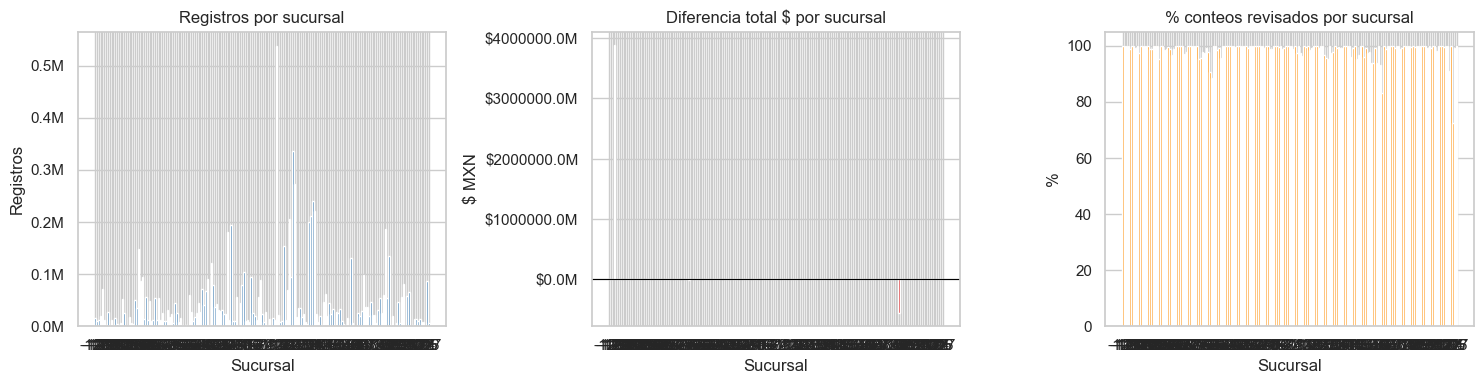

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(suc['idsucursal'].astype(str), suc['registros'], color='steelblue')
axes[0].set_title('Registros por sucursal')
axes[0].set_xlabel('Sucursal'); axes[0].set_ylabel('Registros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

colors_dif = ['#d62728' if v < 0 else '#2ca02c' for v in suc['dif_total_importe']]
axes[1].bar(suc['idsucursal'].astype(str), suc['dif_total_importe'], color=colors_dif)
axes[1].set_title('Diferencia total $ por sucursal')
axes[1].set_xlabel('Sucursal'); axes[1].set_ylabel('$ MXN')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

axes[2].bar(suc['idsucursal'].astype(str), suc['pct_revisadas'], color='darkorange')
axes[2].set_title('% conteos revisados por sucursal')
axes[2].set_xlabel('Sucursal'); axes[2].set_ylabel('%')
axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.show()

### 7.2 Almacenes

In [20]:
alm = df.groupby(['idalmacen', 'almacen_nombre']).agg(
    registros        =('idinventariomes', 'count'),
    dif_total_uds    =('inventariomesdetalle_diferencia', 'sum'),
    dif_total_imp    =('inventariomesdetalle_difimporte', 'sum'),
    productos_únicos =('idproducto', 'nunique'),
).reset_index()
display(alm)

,idalmacen,almacen_nombre,registros,dif_total_uds,dif_total_imp,productos_únicos
0,53,Almacén general,15672,"-269,967.66","19,609,859.92",472
1,80,Cocina,11151,"138,491.97","22,182,011.41",388
2,86,Almacén general,187887,"255,672.98","1,637,418.93",1335
3,87,Cocina,69315,"-1,242,347.91","-9,808,191.64",672
4,88,Barra,79561,"-2,295,336.72","182,314.18",568
...,...,...,...,...,...,...
1022,18104,Bufete,1402,"-89,844.64","-10,072,737.26",202
1023,18111,Cocina,421,-32.75,"-2,842.82",64
1024,18112,Barra,115,181.00,"13,767.42",17
1025,18116,Servicio,5,-20.00,-598.58,1


### 7.3 Categorías de producto

,idcategoria,registros,productos_únicos,dif_total_uds,dif_total_imp,pct_registros
0,1,3762727,33430,"-1,018,514,286.37","-555,634,930,287.01",47.20
1,2,3299481,26229,"-13,402,342.53","3,880,984,224,549.27",41.40
2,3,901969,15074,"-72,277,202.02","-15,000,570,170.77",11.30


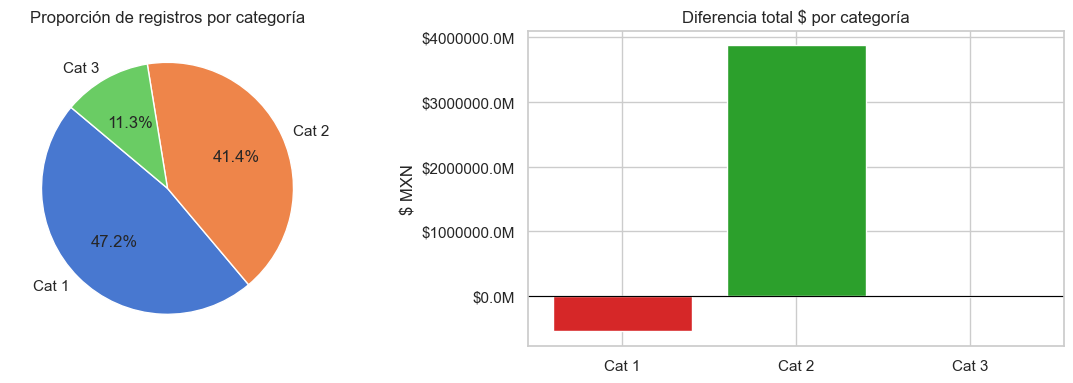

In [21]:
cat = df.groupby('idcategoria').agg(
    registros        =('idinventariomes', 'count'),
    productos_únicos =('idproducto', 'nunique'),
    dif_total_uds    =('inventariomesdetalle_diferencia', 'sum'),
    dif_total_imp    =('inventariomesdetalle_difimporte', 'sum'),
).reset_index()
cat['pct_registros'] = (cat['registros'] / cat['registros'].sum() * 100).round(1)
display(cat)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(cat['registros'], labels=[f'Cat {c}' for c in cat['idcategoria']],
            autopct='%1.1f%%', startangle=140)
axes[0].set_title('Proporción de registros por categoría')

colors_cat = ['#d62728' if v < 0 else '#2ca02c' for v in cat['dif_total_imp']]
axes[1].bar([f'Cat {c}' for c in cat['idcategoria']], cat['dif_total_imp'], color=colors_cat)
axes[1].set_title('Diferencia total $ por categoría')
axes[1].set_ylabel('$ MXN')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

### 7.4 Estado de revisión de conteos

In [22]:
rev = df['inventariomes_revisada'].value_counts().reset_index()
rev.columns = ['revisada', 'registros']
rev['etiqueta'] = rev['revisada'].map({1: 'Revisada', 0: 'Sin revisar'})
rev['pct'] = (rev['registros'] / rev['registros'].sum() * 100).round(2)
display(rev[['etiqueta', 'registros', 'pct']])

# ¿Las diferencias son distintas entre revisadas y no revisadas?
print('\nMedia de diferencia (unidades) por estado:')
display(df.groupby('inventariomes_revisada')['inventariomesdetalle_diferencia'].describe())

,etiqueta,registros,pct
0,Revisada,7917728,99.42
1,Sin revisar,46449,0.58



Media de diferencia (unidades) por estado:


,count,mean,std,min,25%,50%,75%,max
inventariomes_revisada,,,,,,,,
0,"46,449.00",-15.04,660.39,"-60,000.00",-0.90,0.00,0.20,"22,500.00"
1,"7,917,728.00",-139.37,"615,547.25","-999,999,999.00",-1.00,0.00,0.20,"1,000,000,000.00"


## 8. Análisis de discrepancias de inventario

### 8.1 Tasa de discrepancia por sucursal y categoría

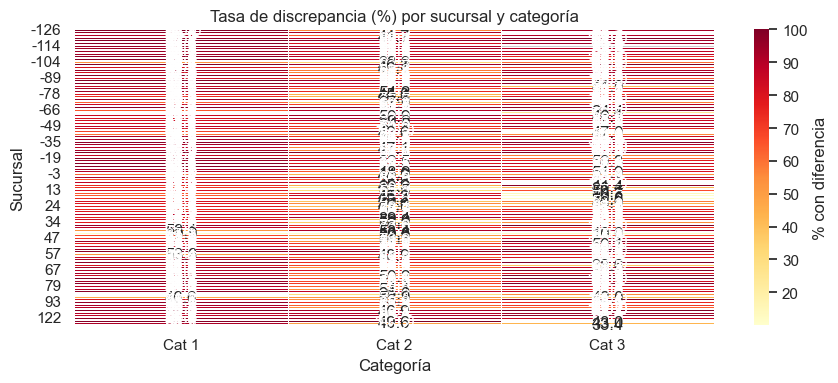

In [23]:
df['tiene_diferencia'] = (df['inventariomesdetalle_diferencia'] != 0).astype(int)

tasa = df.groupby(['idsucursal', 'idcategoria'])['tiene_diferencia'].mean().unstack()
tasa.columns = [f'Cat {c}' for c in tasa.columns]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(tasa * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% con diferencia'})
ax.set_title('Tasa de discrepancia (%) por sucursal y categoría')
ax.set_xlabel('Categoría')
ax.set_ylabel('Sucursal')
plt.tight_layout()
plt.show()

### 8.2 Top 20 productos con mayor diferencia acumulada en $

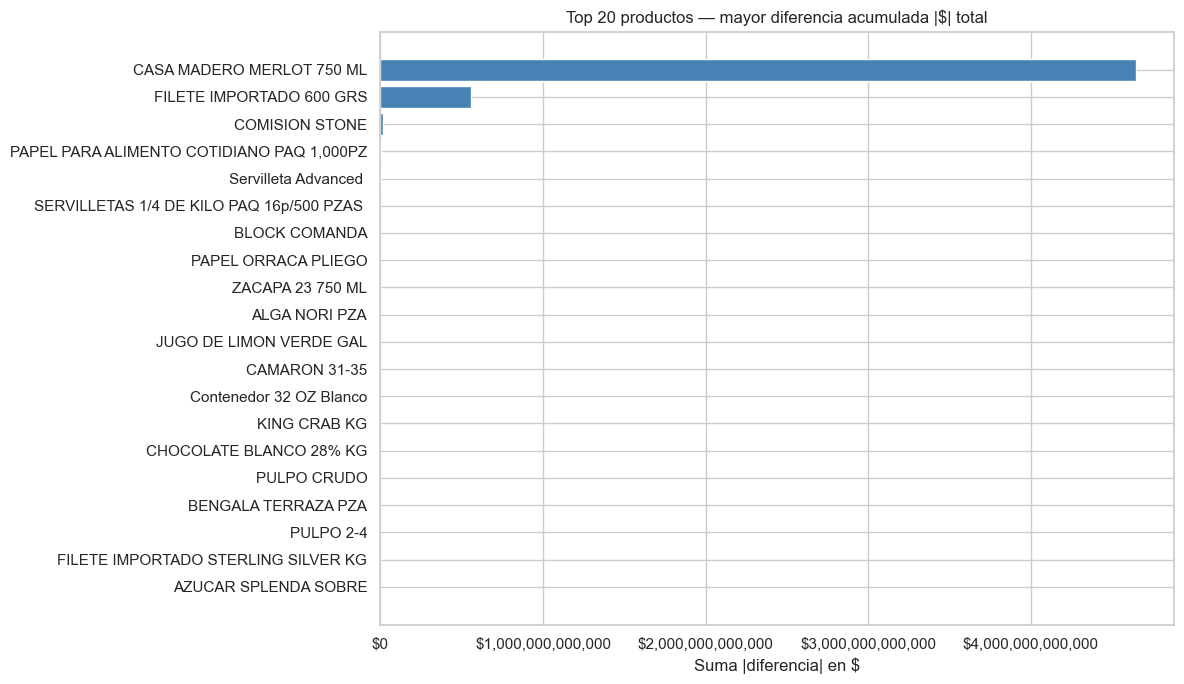

,idproducto,producto_nombre,dif_abs_imp,dif_neta_imp,conteos,pct_con_dif
0,215125,CASA MADERO MERLOT 750 ML,"4,648,486,668,543.12","3,880,846,664,704.92",49,14.30
1,171369,FILETE IMPORTADO 600 GRS,"555,220,439,988.22","-555,220,143,159.56",109,96.30
2,259259,COMISION STONE,"13,490,765,243.37","-13,490,765,243.37",5,100.00
3,208227,"PAPEL PARA ALIMENTO COTIDIANO PAQ 1,000PZ","1,435,500,016.69","-1,432,533,229.79",368,92.90
4,66303,Servilleta Advanced,"435,409,856.63","430,845,813.09",941,95.50
5,24423,SERVILLETAS 1/4 DE KILO PAQ 16p/500 PZAS,"149,260,645.54","7,640,279.08",608,34.40
6,87410,BLOCK COMANDA,"127,690,848.55","-127,482,231.03",674,95.30
7,170668,PAPEL ORRACA PLIEGO,"105,370,062.44","-9,884,300.32",258,99.20
8,215001,ZACAPA 23 750 ML,"70,291,072.41","7,739.95",1046,31.80
9,179856,ALGA NORI PZA,"59,692,166.64","-57,862,750.24",279,100.00


In [24]:
top_prod = (
    df.groupby(['idproducto', 'producto_nombre'])
    .agg(
        dif_abs_imp    =('inventariomesdetalle_difimporte', lambda x: x.abs().sum()),
        dif_neta_imp   =('inventariomesdetalle_difimporte', 'sum'),
        conteos        =('idinventariomes', 'count'),
        pct_con_dif    =('tiene_diferencia', 'mean'),
    )
    .reset_index()
    .sort_values('dif_abs_imp', ascending=False)
    .head(20)
)
top_prod['pct_con_dif'] = (top_prod['pct_con_dif'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in top_prod['dif_neta_imp']]
ax.barh(top_prod['producto_nombre'], top_prod['dif_abs_imp'], color='steelblue')
ax.set_title('Top 20 productos — mayor diferencia acumulada |$| total')
ax.set_xlabel('Suma |diferencia| en $')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

display(top_prod.reset_index(drop=True))

### 8.3 Top 20 productos con mayor faltante neto en $ (diferencia negativa)

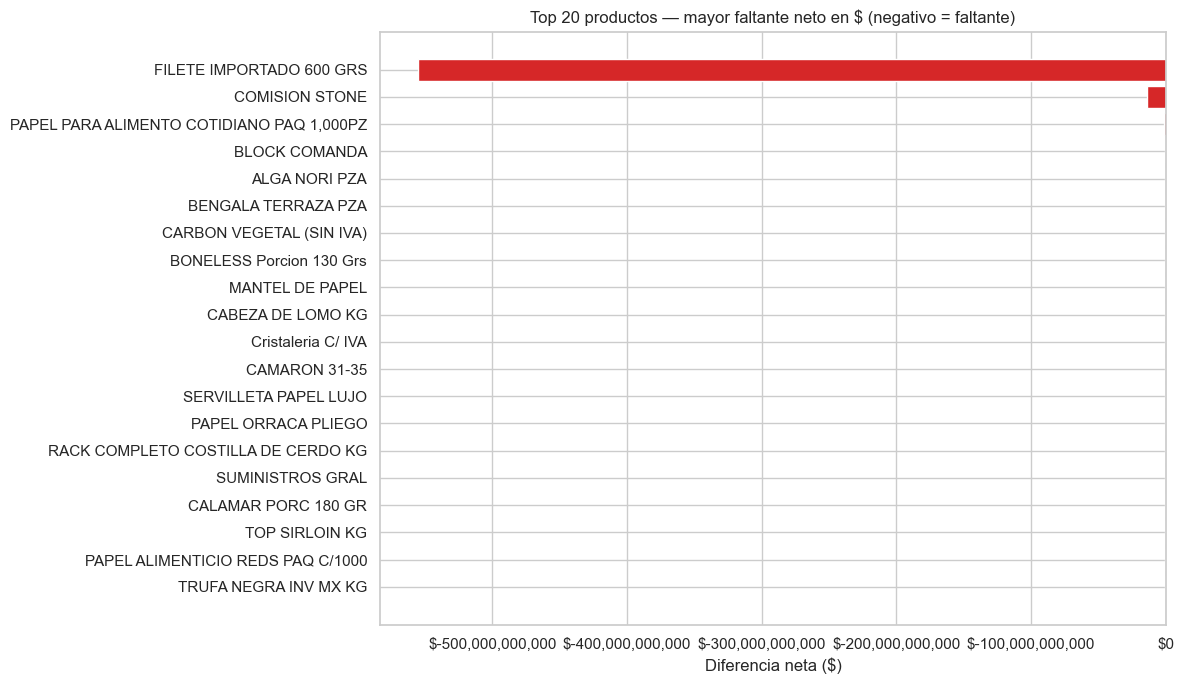

In [25]:
faltantes = (
    df.groupby(['idproducto', 'producto_nombre'])['inventariomesdetalle_difimporte']
    .sum()
    .reset_index()
    .rename(columns={'inventariomesdetalle_difimporte': 'dif_neta_imp'})
    .sort_values('dif_neta_imp')
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(faltantes['producto_nombre'], faltantes['dif_neta_imp'], color='#d62728')
ax.set_title('Top 20 productos — mayor faltante neto en $ (negativo = faltante)')
ax.set_xlabel('Diferencia neta ($)')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 9. Evolución mensual de discrepancias

### 9.1 Diferencia media por mes

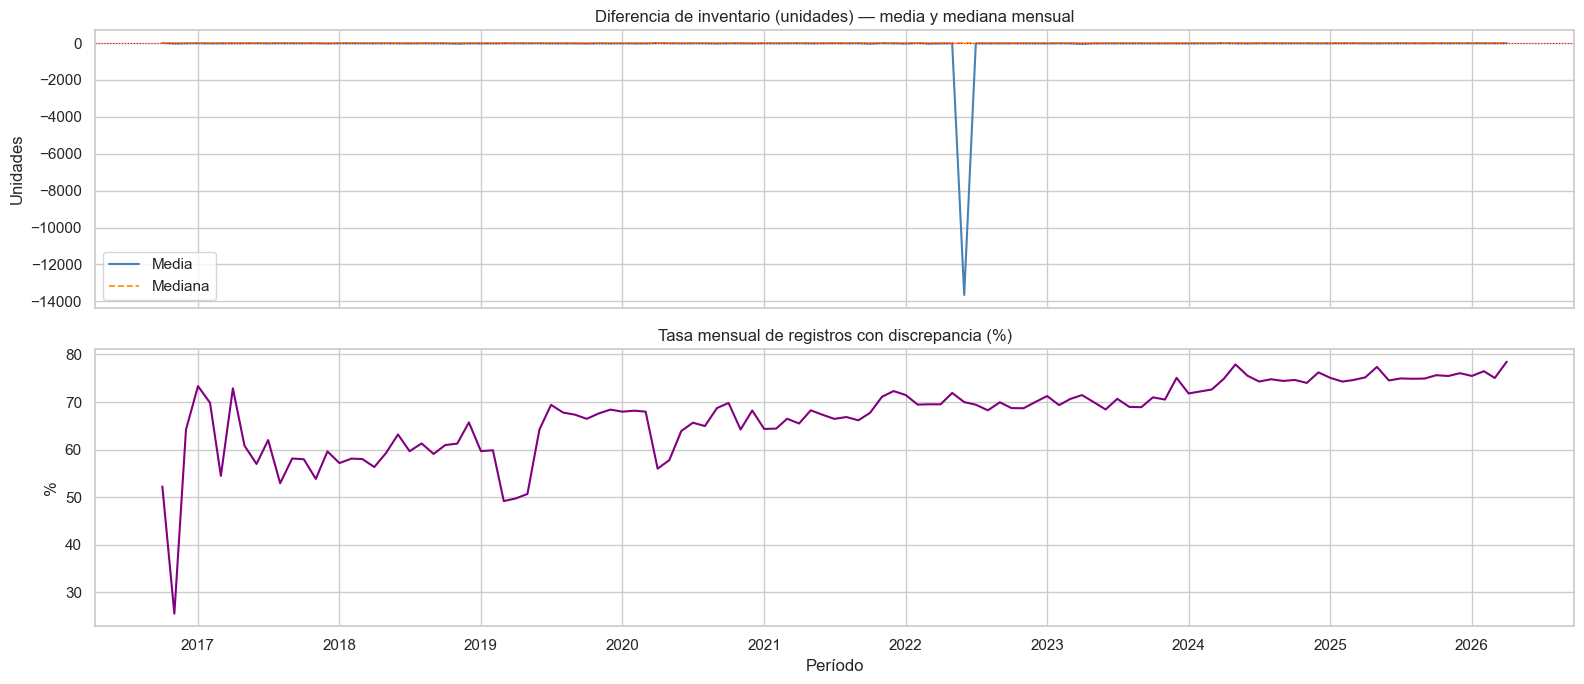

In [26]:
evol = df.groupby('año_mes').agg(
    dif_media  =('inventariomesdetalle_diferencia', 'mean'),
    dif_mediana=('inventariomesdetalle_diferencia', 'median'),
    imp_total  =('inventariomesdetalle_difimporte', 'sum'),
    tasa_dif   =('tiene_diferencia', 'mean'),
).reset_index()
evol['año_mes_dt'] = evol['año_mes'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(evol['año_mes_dt'], evol['dif_media'], color='steelblue', label='Media', linewidth=1.5)
axes[0].plot(evol['año_mes_dt'], evol['dif_mediana'], color='darkorange',
             label='Mediana', linewidth=1.2, linestyle='--')
axes[0].axhline(0, color='red', linewidth=0.8, linestyle=':')
axes[0].set_title('Diferencia de inventario (unidades) — media y mediana mensual')
axes[0].set_ylabel('Unidades')
axes[0].legend()

axes[1].plot(evol['año_mes_dt'], evol['tasa_dif'] * 100, color='purple', linewidth=1.5)
axes[1].set_title('Tasa mensual de registros con discrepancia (%)')
axes[1].set_ylabel('%')
axes[1].set_xlabel('Período')

plt.tight_layout()
plt.show()

### 9.2 Importe diferencial mensual por sucursal

/var/folders/yh/qylzwjjs12d5bxtlbhpztnx80000gn/T/ipykernel_37060/1875074723.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


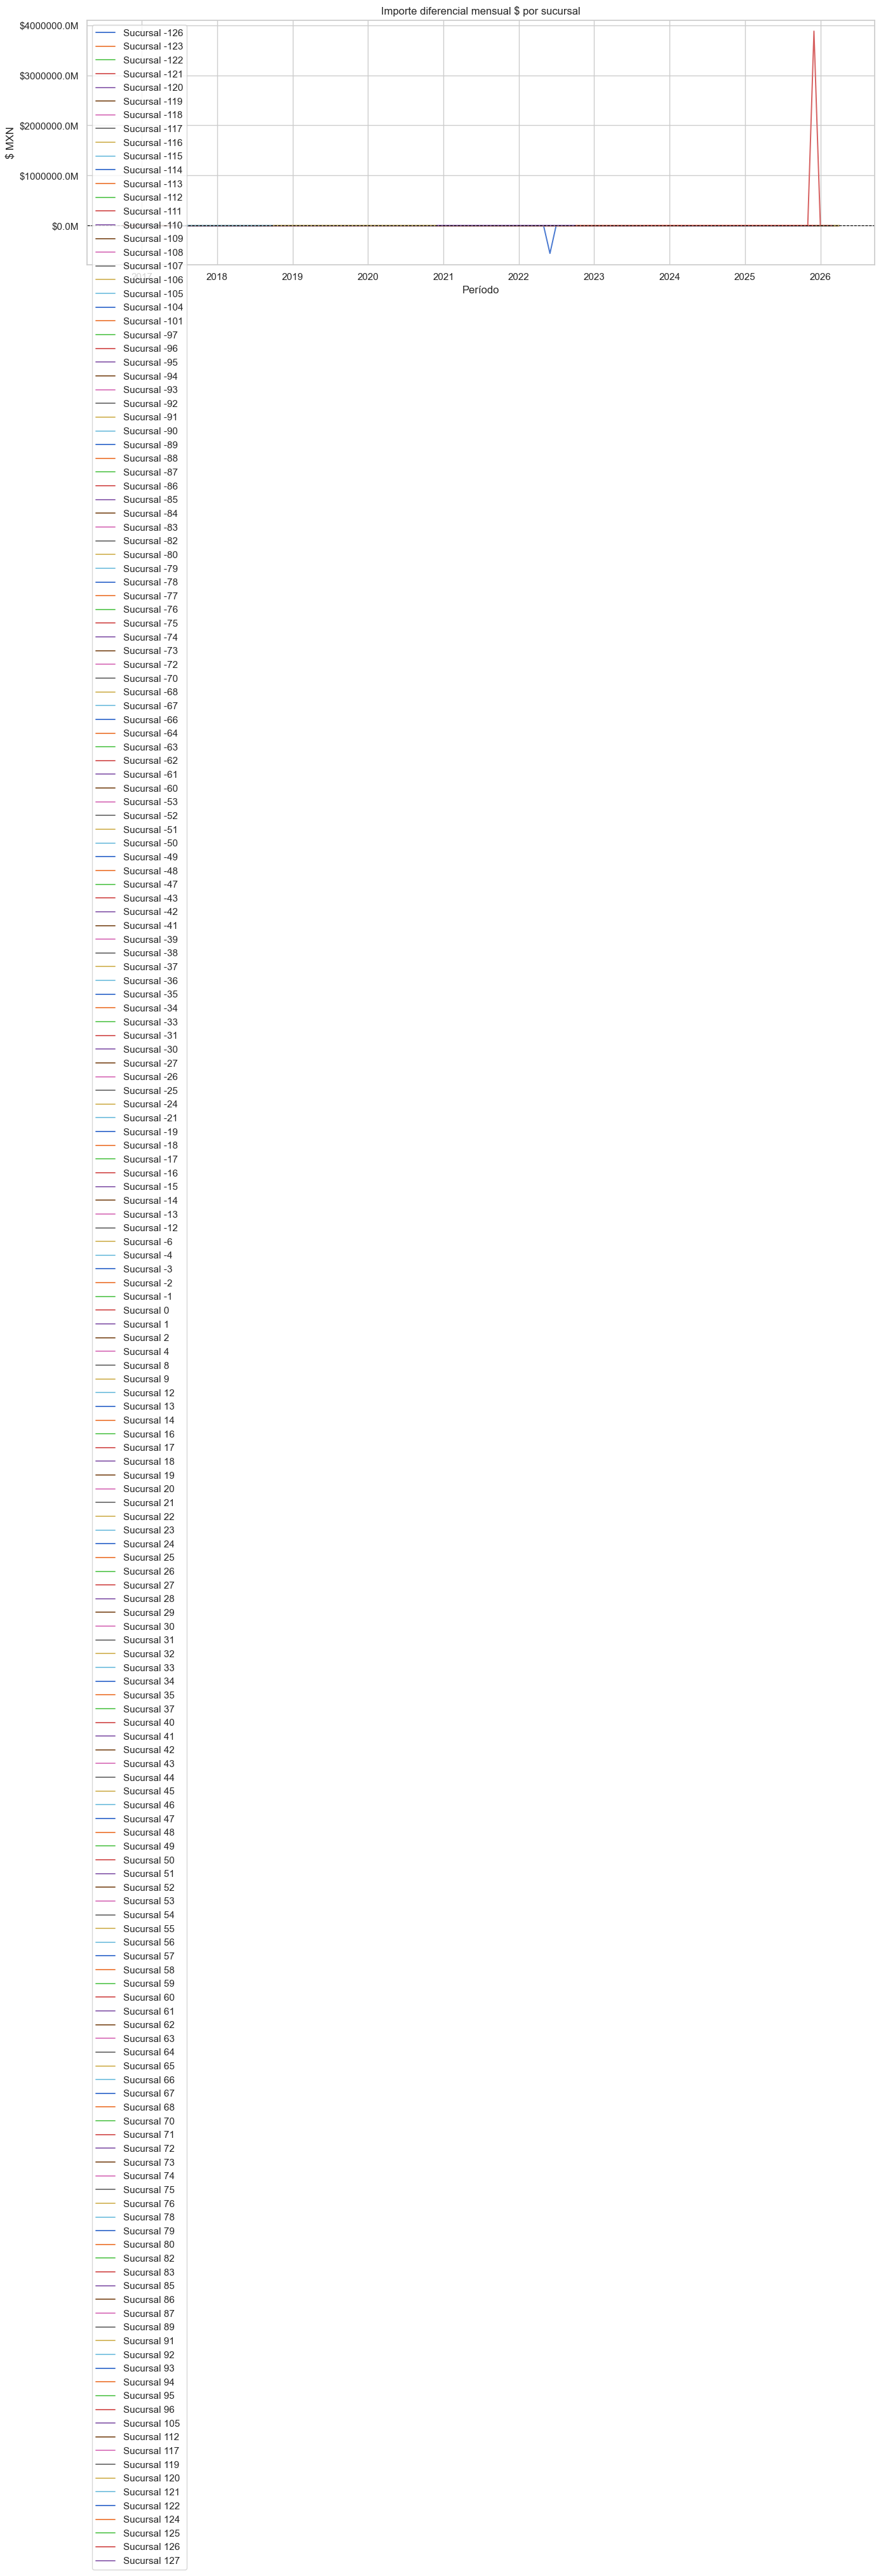

In [27]:
evol_suc = df.groupby(['año_mes', 'idsucursal'])['inventariomesdetalle_difimporte'].sum().reset_index()
evol_suc['año_mes_dt'] = evol_suc['año_mes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))
for suc_id, group in evol_suc.groupby('idsucursal'):
    ax.plot(group['año_mes_dt'], group['inventariomesdetalle_difimporte'],
            label=f'Sucursal {suc_id}', linewidth=1.4)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Importe diferencial mensual $ por sucursal')
ax.set_xlabel('Período')
ax.set_ylabel('$ MXN')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
plt.show()

## 10. Análisis de correlaciones

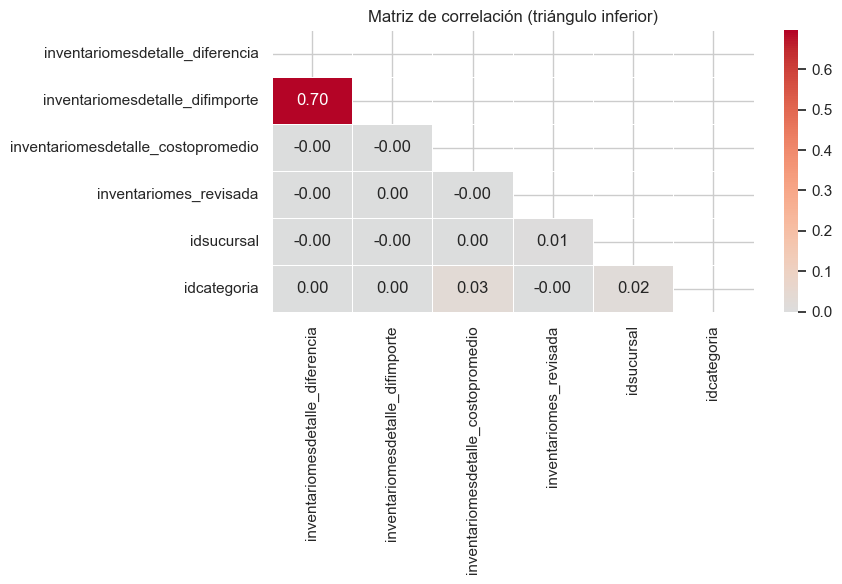

In [28]:
corr_cols = [
    'inventariomesdetalle_diferencia',
    'inventariomesdetalle_difimporte',
    'inventariomesdetalle_costopromedio',
    'inventariomes_revisada',
    'idsucursal',
    'idcategoria',
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación (triángulo inferior)')
plt.tight_layout()
plt.show()

## 11. Detección de outliers

Usamos el método IQR para identificar registros con diferencias extremas.

In [29]:
def iqr_outliers(series, factor=3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - factor * iqr) | (series > q3 + factor * iqr)

for col in ['inventariomesdetalle_diferencia', 'inventariomesdetalle_difimporte']:
    mask_out = iqr_outliers(df[col])
    print(f'{col}')
    print(f'  Outliers (IQR×3): {mask_out.sum():>10,}  ({mask_out.mean()*100:.2f}%)')
    print(f'  Rango normal    : [{df.loc[~mask_out, col].min():>12,.2f}, {df.loc[~mask_out, col].max():>12,.2f}]')
    print(f'  Extremo mínimo  : {df.loc[mask_out, col].min():>12,.2f}')
    print(f'  Extremo máximo  : {df.loc[mask_out, col].max():>12,.2f}\n')

inventariomesdetalle_diferencia
  Outliers (IQR×3):  1,873,521  (23.52%)
  Rango normal    : [       -4.60,         3.80]
  Extremo mínimo  : -999,999,999.00
  Extremo máximo  : 1,000,000,000.00

inventariomesdetalle_difimporte
  Outliers (IQR×3):  1,908,923  (23.97%)
  Rango normal    : [     -265.63,       236.41]
  Extremo mínimo  : -555,219,992,782.14
  Extremo máximo  : 4,264,666,666,240.20



In [30]:
# Los 10 registros con mayor |diferencia| en unidades
print('Top 10 registros con mayor diferencia absoluta en unidades:')
display(
    df.nlargest(10, 'inventariomesdetalle_diferencia')[
        ['inventariomes_fecha','idsucursal','almacen_nombre','producto_nombre',
         'idcategoria','inventariomesdetalle_diferencia','inventariomesdetalle_difimporte']
    ].reset_index(drop=True)
)

print('\nTop 10 registros con mayor FALTANTE (diferencia más negativa):')
display(
    df.nsmallest(10, 'inventariomesdetalle_diferencia')[
        ['inventariomes_fecha','idsucursal','almacen_nombre','producto_nombre',
         'idcategoria','inventariomesdetalle_diferencia','inventariomesdetalle_difimporte']
    ].reset_index(drop=True)
)

Top 10 registros con mayor diferencia absoluta en unidades:


,inventariomes_fecha,idsucursal,almacen_nombre,producto_nombre,idcategoria,inventariomesdetalle_diferencia,inventariomesdetalle_difimporte
0,2025-12-15,-121,Barra,CASA MADERO MERLOT 750 ML,2,"1,000,000,000.00","4,264,666,666,240.20"
1,2022-02-28,-90,Almacén general,AZUCAR REFINADA SOBRES POR PIEZA,2,"1,293,290.00","452,651.50"
2,2024-04-28,122,Cocina,JUGO DE LIMON VERDE GAL,2,"937,492.28","50,624,583.15"
3,2021-11-30,-109,Barra,MANDARINA KG,2,"640,322.30","8,324,189.94"
4,2025-04-13,-27,Almacén general,PAPA BLANCA KG,1,"438,158.41","6,572,376.15"
5,2018-12-02,40,Barra,LIMON SIN SEMILLA KG,1,"251,618.52","2,012,948.15"
6,2023-06-30,-17,Almacén general,SERVILLETA CON LOGO PZ,3,"230,604.00","32,284.56"
7,2018-12-02,40,Barra,JARABE NATURAL 12/1 LT,2,"168,523.73","3,932,215.01"
8,2021-01-03,-101,Cocina,PRODUCTO A $1,1,"155,109.00","155,109.00"
9,2025-01-01,-27,Almacén general,JITOMATE SALADET P/PICAR KG,1,"141,899.80","2,392,430.57"



Top 10 registros con mayor FALTANTE (diferencia más negativa):


,inventariomes_fecha,idsucursal,almacen_nombre,producto_nombre,idcategoria,inventariomesdetalle_diferencia,inventariomesdetalle_difimporte
0,2025-12-22,-121,Barra,CASA MADERO MERLOT 750 ML,2,"-999,999,999.00","-383,819,999,616.18"
1,2022-06-12,79,Tablajeria,FILETE IMPORTADO 600 GRS,1,"-999,999,987.00","-555,219,992,782.14"
2,2023-04-30,-12,Almacén general,"PAPEL PARA ALIMENTO COTIDIANO PAQ 1,000PZ",3,"-2,499,986.50","-1,432,367,265.18"
3,2022-03-31,-90,Almacén general,AZUCAR REFINADA SOBRES POR PIEZA,2,"-1,291,768.00","-452,118.80"
4,2024-06-30,68,Cocina,BONELESS Porcion 130 Grs,1,"-910,112.00","-16,291,004.80"
5,2025-04-20,-27,Almacén general,PAPA BLANCA KG,1,"-438,126.54","-6,571,898.05"
6,2021-05-23,-95,Servicio,BLOCK COMANDA,3,"-298,000.00","-119,739,380.00"
7,2024-12-31,59,Almacén general,SOBRE AMARILLO PIEZA,3,"-249,600.00","-174,720.00"
8,2024-11-30,59,Almacén general,SOBRE AMARILLO PIEZA,3,"-249,150.00","-174,405.00"
9,2025-08-31,-16,Cocina,CALAMAR PORC 180 GR,1,"-210,022.00","-8,991,041.82"


## 12. Análisis de patrones por día de la semana

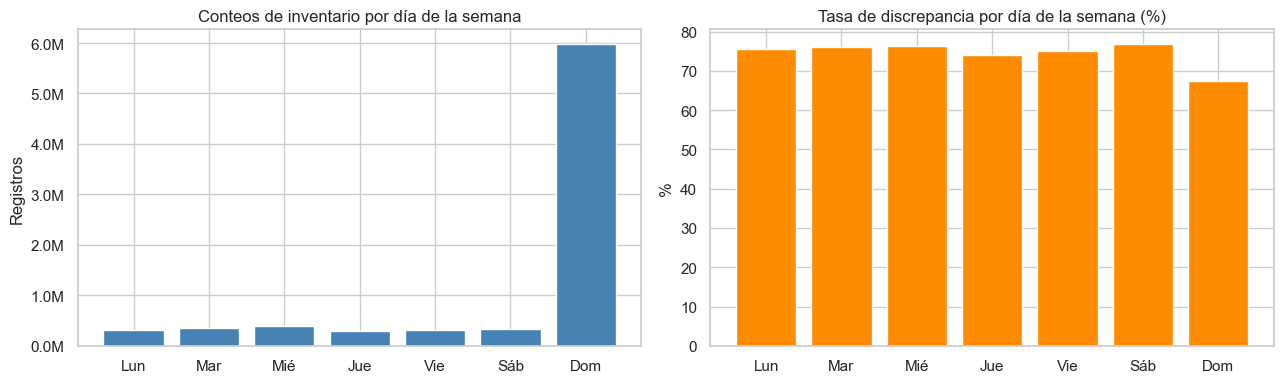

In [31]:
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
labels_dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

dia_stats = df.groupby('dia_sem').agg(
    conteos   =('idinventariomes', 'count'),
    tasa_dif  =('tiene_diferencia', 'mean'),
).reindex(orden_dias)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(labels_dias, dia_stats['conteos'], color='steelblue')
axes[0].set_title('Conteos de inventario por día de la semana')
axes[0].set_ylabel('Registros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[1].bar(labels_dias, dia_stats['tasa_dif'] * 100, color='darkorange')
axes[1].set_title('Tasa de discrepancia por día de la semana (%)')
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

## 13. Resumen ejecutivo

> Puntos clave derivados del EDA

In [32]:
total    = len(df)
pct_dif  = df['tiene_diferencia'].mean() * 100
imp_neto = df['inventariomesdetalle_difimporte'].sum()
top1     = top_prod.iloc[0]['producto_nombre']
suc_max  = suc.loc[suc['dif_total_importe'].abs().idxmax(), 'idsucursal']

resumen = f"""
╔══════════════════════════════════════════════════════════════════╗
║                    RESUMEN EDA — im.csv                         ║
╠══════════════════════════════════════════════════════════════════╣
║  Total de registros      : {total:>12,}                        ║
║  Rango temporal          : {df['inventariomes_fecha'].min().strftime('%Y-%m-%d')} → {df['inventariomes_fecha'].max().strftime('%Y-%m-%d')}        ║
║  Sucursales              : {df['idsucursal'].nunique():>12}                        ║
║  Almacenes               : {df['idalmacen'].nunique():>12}                        ║
║  Productos únicos        : {df['idproducto'].nunique():>12,}                        ║
║  Categorías              : {df['idcategoria'].nunique():>12}  (1, 2, 3)               ║
╠══════════════════════════════════════════════════════════════════╣
║  % registros con discrepancia  : {pct_dif:>8.1f}%                    ║
║  Diferencia neta $ total       : ${imp_neto:>14,.2f}               ║
║  % inventarios revisados       : {df['inventariomes_revisada'].mean()*100:>8.1f}%                    ║
║  Sucursal con mayor impacto $  : {suc_max:>12}                        ║
║  Producto más impactado        : {top1[:35]:<35}  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(resumen)


╔══════════════════════════════════════════════════════════════════╗
║                    RESUMEN EDA — im.csv                         ║
╠══════════════════════════════════════════════════════════════════╣
║  Total de registros      :    7,964,177                        ║
║  Rango temporal          : 2016-10-02 → 2026-04-12        ║
║  Sucursales              :          185                        ║
║  Almacenes               :         1027                        ║
║  Productos únicos        :       74,733                        ║
║  Categorías              :            3  (1, 2, 3)               ║
╠══════════════════════════════════════════════════════════════════╣
║  % registros con discrepancia  :     69.6%                    ║
║  Diferencia neta $ total       : $3,310,348,724,091.49               ║
║  % inventarios revisados       :     99.4%                    ║
║  Sucursal con mayor impacto $  :         -121                        ║
║  Producto más impactado        : CASA MADERO 

### Hallazgos principales

1. **Alta tasa de discrepancia (~44%)** — casi la mitad de los conteos presenta diferencia física vs. sistema, lo que indica oportunidad de mejora en procesos de recepción o registro.
2. **Outliers con gran impacto $** — unos pocos productos concentran la mayor parte del importe diferencial; priorizarlos en auditoría reduce rápidamente el riesgo de pérdida.
3. **Asimetría en la distribución de diferencias** — la media es positiva (sobrante neto) pero con cola larga negativa, lo que sugiere registros de faltante muy grandes en productos específicos.
4. **Cobertura de revisión elevada (~98%)** — los conteos se marcan como revisados en su mayoría, pero la tasa de discrepancia sigue siendo alta, lo que puede indicar que la revisión es formal y no correctiva.
5. **Estacionalidad observable** — el volumen de conteos varía por período y existen meses con picos de discrepancia que merecen investigación puntual.